In [1]:
import pandas as pd
import numpy as np

In [8]:
df = pd.read_csv(r"D:\ELevate labs\Task-1-Data-Cleaning-Preprocessing\notebook\customer_master.csv")

In [9]:
df.head()

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost
0,CUST-000001,Donna Miller,54,Female,Consumer,Laurenland,Dubai,UAE,South,11253,13.58
1,CUST-000002,Joseph James,61,Male,Consumer,Lake Peter,Lower Saxony,Germany,North,47778,27.45
2,CUST-000003,Daniel Smith,47,Male,Consumer,Seanview,North Rhine,Germany,West,13900,31.53
3,CUST-000004,David Lopez,30,Male,VIP,Hawkinshaven,Pennsylvania,USA,East,53984,16.02
4,CUST-000005,Dakota Davis,55,Female,Consumer,New Carlymouth,Florida,USA,South,50994,41.34


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 25000
Number of columns: 11


In [11]:
df.columns

Index(['customer_id', 'customer_name', 'customer_age', 'gender',
       'customer_segment', 'customer_city', 'customer_state',
       'customer_country', 'region', 'customer_postal_code',
       'customer_acquisition_cost'],
      dtype='str')

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                25000 non-null  str    
 1   customer_name              25000 non-null  str    
 2   customer_age               25000 non-null  int64  
 3   gender                     25000 non-null  str    
 4   customer_segment           25000 non-null  str    
 5   customer_city              25000 non-null  str    
 6   customer_state             25000 non-null  str    
 7   customer_country           25000 non-null  str    
 8   region                     25000 non-null  str    
 9   customer_postal_code       25000 non-null  int64  
 10  customer_acquisition_cost  25000 non-null  float64
dtypes: float64(1), int64(2), str(8)
memory usage: 2.1 MB


In [13]:
df.describe()

,customer_age,customer_postal_code,customer_acquisition_cost
count,25000.000000,25000.000000,25000.000000
mean,45.907840,50183.066400,42.159750
std,16.454286,28596.584321,21.692648
min,18.000000,516.000000,5.010000
25%,32.000000,25374.500000,23.297500
50%,46.000000,50303.000000,41.980000
75%,60.000000,74845.500000,61.130000
max,74.000000,99950.000000,79.990000


In [14]:
df.isnull().sum()

customer_id                  0
customer_name                0
customer_age                 0
gender                       0
customer_segment             0
customer_city                0
customer_state               0
customer_country             0
region                       0
customer_postal_code         0
customer_acquisition_cost    0
dtype: int64

In [15]:
missing_data = pd.DataFrame({
    "Missing_Values": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df)) * 100
})

missing_data

,Missing_Values,Missing_Percentage
customer_id,0,0.0
customer_name,0,0.0
customer_age,0,0.0
gender,0,0.0
customer_segment,0,0.0
customer_city,0,0.0
customer_state,0,0.0
customer_country,0,0.0
region,0,0.0
customer_postal_code,0,0.0


In [16]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [17]:
df[df.duplicated()]

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost


In [18]:
df.dtypes

customer_id                      str
customer_name                    str
customer_age                   int64
gender                           str
customer_segment                 str
customer_city                    str
customer_state                   str
customer_country                 str
region                           str
customer_postal_code           int64
customer_acquisition_cost    float64
dtype: object

In [19]:
df["gender"].value_counts()

gender
Female        12048
Male          11976
Non-Binary      976
Name: count, dtype: int64

In [21]:
df["customer_segment"].value_counts()

customer_segment
Consumer    13638
Premium      6301
VIP          2542
Business     2519
Name: count, dtype: int64

In [22]:
df["customer_country"].value_counts()

customer_country
USA          14925
UK            3701
Germany       2046
Canada        1279
Australia     1233
India         1041
UAE            775
Name: count, dtype: int64

In [23]:
df["customer_state"].value_counts()

customer_state
Pennsylvania         1632
Georgia              1530
California           1530
New York             1517
Ohio                 1496
Michigan             1483
Texas                1463
Illinois             1439
North Carolina       1434
Florida              1401
Northern Ireland      959
England               947
Wales                 902
Scotland              893
North Rhine           430
Hesse                 415
Baden-Württemberg     409
Lower Saxony          397
Bavaria               395
South Australia       292
British Columbia      281
Alberta               264
Manitoba              261
Western Australia     254
New South Wales       252
Victoria              244
Ontario               237
Quebec                236
Karnataka             225
Uttar Pradesh         223
Maharashtra           207
Abu Dhabi             204
Dubai                 200
Tamil Nadu            199
Sharjah               191
Queensland            191
Gujarat               187
Ajman                 1

In [24]:
df["customer_city"].value_counts().head(30)

customer_city
South Michael        30
Lake Michael         30
East Michael         23
Port Michael         21
South James          20
New David            19
New Robert           18
West Christopher     17
North David          17
New John             17
West Michael         17
South John           16
South Christopher    16
Port Robert          16
East James           15
West Jessica         15
Robertmouth          15
South Robert         15
Smithmouth           15
North Michael        15
Lake Christopher     15
New Michael          15
New Christopher      15
Port Jennifer        15
North Robert         14
Port John            14
East David           14
East Robert          14
South Jessica        14
Ashleyview           14
Name: count, dtype: int64

In [25]:
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    leading_spaces = df[col].astype(str).str.startswith(" ").sum()
    trailing_spaces = df[col].astype(str).str.endswith(" ").sum()
    
    print(f"{col}: Leading spaces = {leading_spaces}, Trailing spaces = {trailing_spaces}")

customer_id: Leading spaces = 0, Trailing spaces = 0
customer_name: Leading spaces = 0, Trailing spaces = 0
gender: Leading spaces = 0, Trailing spaces = 0
customer_segment: Leading spaces = 0, Trailing spaces = 0
customer_city: Leading spaces = 0, Trailing spaces = 0
customer_state: Leading spaces = 0, Trailing spaces = 0
customer_country: Leading spaces = 0, Trailing spaces = 0
region: Leading spaces = 0, Trailing spaces = 0


C:\Users\SUBAS\AppData\Local\Temp\ipykernel_19844\692451829.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


In [26]:
print("Total customer IDs:", df["customer_id"].count())
print("Unique customer IDs:", df["customer_id"].nunique())

Total customer IDs: 25000
Unique customer IDs: 25000


In [27]:
df["customer_id"].duplicated().sum()

np.int64(0)

In [28]:
print("Minimum age:", df["customer_age"].min())
print("Maximum age:", df["customer_age"].max())

Minimum age: 18
Maximum age: 74


In [29]:
df[(df["customer_age"] < 18) | (df["customer_age"] > 100)]

,customer_id,customer_name,customer_age,gender,customer_segment,customer_city,customer_state,customer_country,region,customer_postal_code,customer_acquisition_cost


In [30]:
print("Minimum acquisition cost:", df["customer_acquisition_cost"].min())
print("Maximum acquisition cost:", df["customer_acquisition_cost"].max())

Minimum acquisition cost: 5.01
Maximum acquisition cost: 79.99


In [31]:
df["customer_acquisition_cost"].describe()
print("Minimum postal code:", df["customer_postal_code"].min())
print("Maximum postal code:", df["customer_postal_code"].max())
df["customer_postal_code"].astype(str).str.len().value_counts().sort_index()

Minimum postal code: 516
Maximum postal code: 99950


customer_postal_code
3      124
4     2252
5    22624
Name: count, dtype: int64

In [32]:
df["gender"].value_counts()
df["customer_segment"].value_counts()
df["customer_country"].value_counts()
df["region"].value_counts()
df["customer_state"].value_counts()
df["customer_city"].value_counts().head(30)



customer_city
South Michael        30
Lake Michael         30
East Michael         23
Port Michael         21
South James          20
New David            19
New Robert           18
West Christopher     17
North David          17
New John             17
West Michael         17
South John           16
South Christopher    16
Port Robert          16
East James           15
West Jessica         15
Robertmouth          15
South Robert         15
Smithmouth           15
North Michael        15
Lake Christopher     15
New Michael          15
New Christopher      15
Port Jennifer        15
North Robert         14
Port John            14
East David           14
East Robert          14
South Jessica        14
Ashleyview           14
Name: count, dtype: int64

In [34]:
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    leading_spaces = df[col].astype(str).str.startswith(" ").sum()
    trailing_spaces = df[col].astype(str).str.endswith(" ").sum()
    
    print(f"{col}: Leading spaces = {leading_spaces}, Trailing spaces = {trailing_spaces}")

customer_id: Leading spaces = 0, Trailing spaces = 0
customer_name: Leading spaces = 0, Trailing spaces = 0
gender: Leading spaces = 0, Trailing spaces = 0
customer_segment: Leading spaces = 0, Trailing spaces = 0
customer_city: Leading spaces = 0, Trailing spaces = 0
customer_state: Leading spaces = 0, Trailing spaces = 0
customer_country: Leading spaces = 0, Trailing spaces = 0
region: Leading spaces = 0, Trailing spaces = 0


C:\Users\SUBAS\AppData\Local\Temp\ipykernel_19844\692451829.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


In [36]:
print("Total customer IDs:", df["customer_id"].count())
print("Unique customer IDs:", df["customer_id"].nunique())
print("Duplicate customer IDs:", df["customer_id"].duplicated().sum())

Total customer IDs: 25000
Unique customer IDs: 25000
Duplicate customer IDs: 0


In [37]:
text_columns = df.select_dtypes(include=["object", "string"]).columns

for col in text_columns:
    df[col] = df[col].astype("string").str.strip()
df = df.dropna()
df["customer_postal_code"] = df["customer_postal_code"].astype("string")
df["customer_postal_code"] = df["customer_postal_code"].astype("string")
df["customer_age"] = df["customer_age"].astype(int)
print("Cleaned dataset shape:", df.shape)
print(df.head())

Cleaned dataset shape: (25000, 11)
   customer_id customer_name  customer_age  gender customer_segment  \
0  CUST-000001  Donna Miller            54  Female         Consumer   
1  CUST-000002  Joseph James            61    Male         Consumer   
2  CUST-000003  Daniel Smith            47    Male         Consumer   
3  CUST-000004   David Lopez            30    Male              VIP   
4  CUST-000005  Dakota Davis            55  Female         Consumer   

    customer_city customer_state customer_country region customer_postal_code  \
0      Laurenland          Dubai              UAE  South                11253   
1      Lake Peter   Lower Saxony          Germany  North                47778   
2        Seanview    North Rhine          Germany   West                13900   
3    Hawkinshaven   Pennsylvania              USA   East                53984   
4  New Carlymouth        Florida              USA  South                50994   

   customer_acquisition_cost  
0                   

In [38]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
df["gender"].value_counts()
df["gender"].value_counts()
df["customer_segment"].value_counts()
df["customer_country"].value_counts()
df["customer_age"].describe()


Dataset Shape: (25000, 11)

Column Names:
['customer_id', 'customer_name', 'customer_age', 'gender', 'customer_segment', 'customer_city', 'customer_state', 'customer_country', 'region', 'customer_postal_code', 'customer_acquisition_cost']


count    25000.000000
mean        45.907840
std         16.454286
min         18.000000
25%         32.000000
50%         46.000000
75%         60.000000
max         74.000000
Name: customer_age, dtype: float64

In [40]:
%pip install matplotlib

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.5 MB 5.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.1/9.5 MB 4.8 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 5.5 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 5.2 MB/s eta 0:00:01
   ----------------------- ---------------- 5.5/9.5 MB 5.3 MB/s eta 0:00:01
   ----------------------------- ---------- 7.1/9.5 MB 5.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 5.8 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 5.6 MB/s  0:00:01
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------- ----------------------- 1.0/2.5 MB 4.6 MB/s eta 0:00:01
   ----------------------------- ---------- 1.8/2.5 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 4.1 MB/s  0:00:00
   -----------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


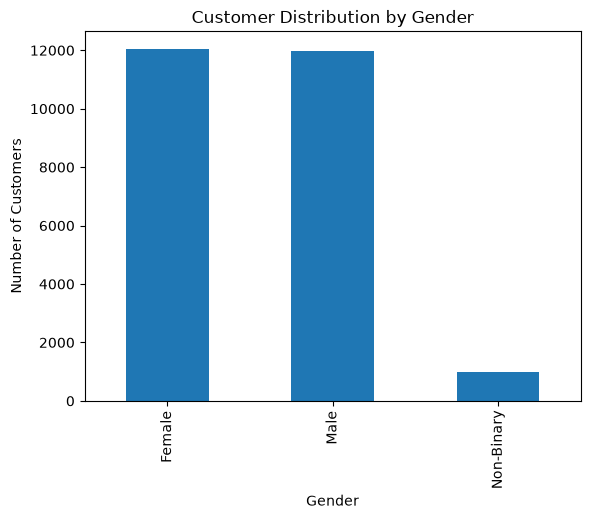

In [41]:
import matplotlib.pyplot as plt

df["gender"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

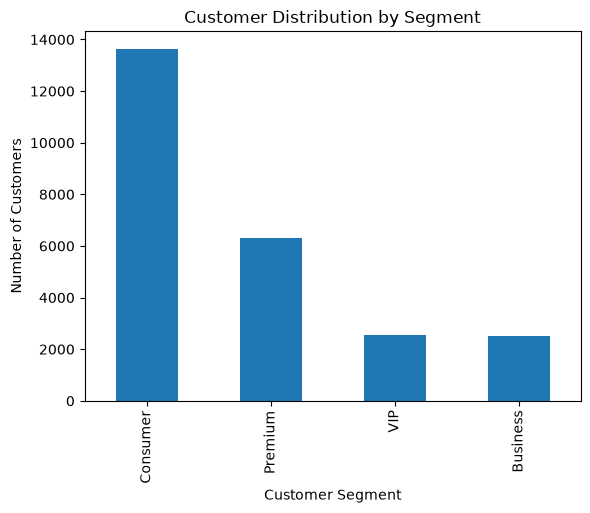

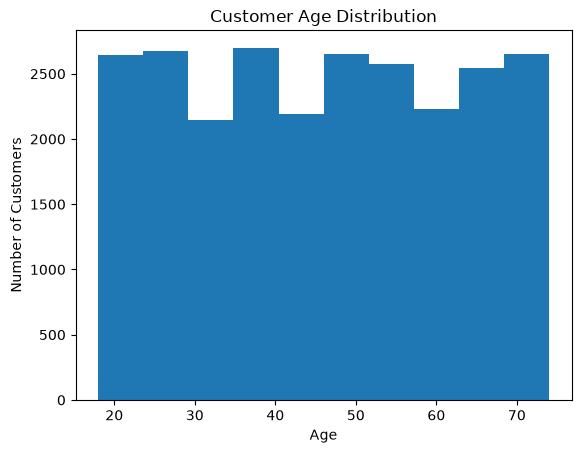

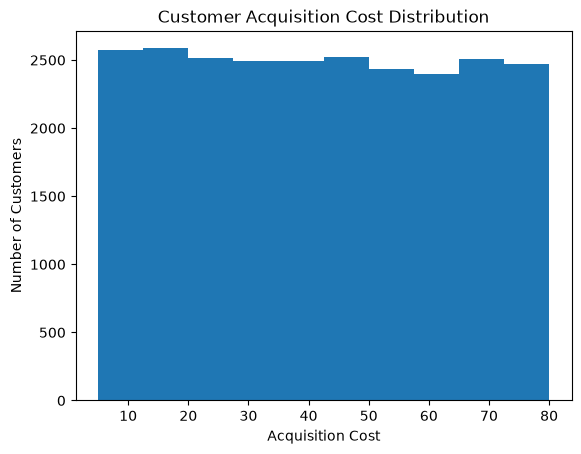

In [42]:
df["customer_segment"].value_counts().plot(kind="bar")

plt.title("Customer Distribution by Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")
plt.show()
df["customer_age"].plot(kind="hist", bins=10)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

df["customer_acquisition_cost"].plot(kind="hist", bins=10)

plt.title("Customer Acquisition Cost Distribution")
plt.xlabel("Acquisition Cost")
plt.ylabel("Number of Customers")
plt.show()

In [43]:
print("Final Dataset Shape:", df.shape)
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Data Types:")
print(df.dtypes)

Final Dataset Shape: (25000, 11)
Missing Values: 0
Duplicate Rows: 0
Data Types:
customer_id                   string
customer_name                 string
customer_age                   int64
gender                        string
customer_segment              string
customer_city                 string
customer_state                string
customer_country              string
region                        string
customer_postal_code          string
customer_acquisition_cost    float64
dtype: object


In [44]:
df.to_csv("cleaned_customer_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


# Conclusion

The customer dataset was successfully cleaned and preprocessed.

The cleaning process included:
- Removing missing values
- Removing duplicate records
- Removing unnecessary spaces from text columns
- Converting columns to appropriate data types
- Validating customer age and acquisition cost
- Checking categorical values
- Checking customer ID uniqueness
- Performing basic statistical analysis
- Visualizing customer distributions

The final cleaned dataset contains 25,000 records and 11 columns.

The cleaned dataset is now ready for further data analysis and visualization.